In [1]:
!pip -q install pandas numpy scikit-learn joblib matplotlib


In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import matplotlib.pyplot as plt


In [3]:
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
print("Uploaded:", file_name)

df = pd.read_csv(file_name)
df.head()


Saving processed_emails.csv to processed_emails.csv
Uploaded: processed_emails.csv


,subject,body,clean_text,category,urgency,date
0,Anniversary Special: Buy one get one free,"As our loyal customer, get exclusive $60 off $...",anniversary special buy one get one free as ou...,spam,medium,2026-02-10
1,Your Amazon was used on new device,Your $5000 refund is processed. Claim: bit.ly/...,your amazon was used on new device your 5000 r...,complaints,medium,2026-02-10
2,Re: Your Google inquiry,"Hi, following up about your Google application...","re your google inquiry hi, following up about ...",spam,medium,2026-02-10
3,Digital Ritual Experience Creation,Cross-cultural ceremony design. Join: virtualr...,digital ritual experience creation cross-cultu...,requests,medium,2026-02-10
4,"Your post was moved to ""Programming Help""","Trending: ""cooking"" (258 comments). View: supp...",your post was moved to programming help trendi...,requests,medium,2026-02-10


In [4]:
print("Shape:", df.shape)
print(df["category"].value_counts())

# ensure required columns
assert "clean_text" in df.columns, "clean_text column missing"
assert "category" in df.columns, "category column missing"


Shape: (9979, 6)
category
requests      7112
spam          1500
complaints     958
feedback       409
Name: count, dtype: int64


In [5]:
X = df["clean_text"].fillna("").astype(str)
y = df["category"].fillna("").astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (7983,) Test: (1996,)


In [6]:
lr_clf = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        n_jobs=-1
    ))
])

lr_clf.fit(X_train, y_train)
print("LR training done")


LR training done


In [7]:
lr_pred = lr_clf.predict(X_test)

print("LR Accuracy:", accuracy_score(y_test, lr_pred))
print("\nClassification Report (LR):\n")
print(classification_report(y_test, lr_pred))


LR Accuracy: 0.9719438877755511

Classification Report (LR):

              precision    recall  f1-score   support

  complaints       0.91      0.97      0.94       192
    feedback       0.89      0.89      0.89        82
    requests       0.99      0.97      0.98      1422
        spam       0.96      0.99      0.97       300

    accuracy                           0.97      1996
   macro avg       0.94      0.95      0.95      1996
weighted avg       0.97      0.97      0.97      1996



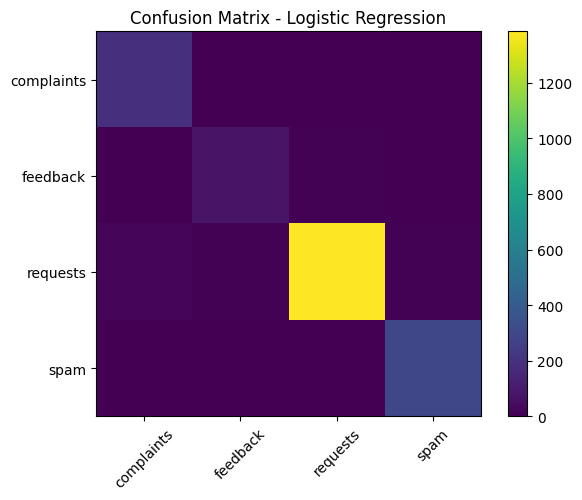

array([[ 186,    0,    5,    1],
       [   0,   73,    7,    2],
       [  18,    9, 1385,   10],
       [   1,    0,    3,  296]])

In [8]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, lr_pred, labels=labels)

plt.figure(figsize=(7,5))
plt.imshow(cm)
plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)
plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()
plt.show()

cm


In [9]:
nb_clf = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),
        min_df=2,
        max_df=0.95
    )),
    ("model", MultinomialNB(alpha=0.5))
])

nb_clf.fit(X_train, y_train)
print("NB training done ")


NB training done 


In [10]:
nb_pred = nb_clf.predict(X_test)

print("NB Accuracy:", accuracy_score(y_test, nb_pred))
print("\nClassification Report (NB):\n")
print(classification_report(y_test, nb_pred))


NB Accuracy: 0.8607214428857716

Classification Report (NB):

              precision    recall  f1-score   support

  complaints       0.78      0.86      0.82       192
    feedback       0.71      0.80      0.75        82
    requests       0.97      0.84      0.90      1422
        spam       0.63      0.95      0.76       300

    accuracy                           0.86      1996
   macro avg       0.77      0.87      0.81      1996
weighted avg       0.89      0.86      0.87      1996



In [11]:
results = pd.DataFrame({
    "clean_text": X_test,
    "true_category": y_test,
    "pred_lr": lr_pred,
    "pred_nb": nb_pred
})

results.to_csv("category_results.csv", index=False)
print("Saved: category_results.csv ")
results.head()


Saved: category_results.csv 


,clean_text,true_category,pred_lr,pred_nb
9760,new follower sarah johnson mike anyone free th...,spam,spam,feedback
7825,zelle payment pending 250 from emily chen. acc...,requests,requests,requests
5753,"crypto opportunity 200 roi guaranteed hi, foll...",spam,spam,spam
8125,"your appointment confirmed sep 1, midnight-2am...",complaints,complaints,complaints
1229,delivery problem ab-123 see who messaged you o...,complaints,complaints,spam


In [12]:
joblib.dump(lr_clf, "category_model_lr.pkl")
joblib.dump(nb_clf, "category_model_nb.pkl")

print("Saved models")


Saved models
